In [1]:
%load_ext autoreload
%autoreload 2

from src.constants import PROCESSED_DATA_PATH, INTERIM_DATA_PATH
from src.utils import (
    hd_tuning, circ_colors, plot_tuning_grid,
    fit_von_mises, fit_all_tuning_curves, 
    plot_von_mises_fit, plot_all_von_mises_fits, von_mises
)

import numpy as np
import pandas as pd
import pynapple as nap
import seaborn as sns
from matplotlib import pyplot as plt
import xarray as xr

custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(style="ticks", palette="colorblind", font_scale=1.5, rc=custom_params)

prj = nap.load_folder(PROCESSED_DATA_PATH.parent)
prj.view

📂 ucsf
├── 📂 external
│   └── 📂 107b
├── 📂 interim
│   └── 📂 107b
│       ├── 📂 umap_correlation
│       ├── 📂 umap_cosine
│       ├── 📂 umap_euclidean
│       ├── 📂 umap_mahalanobis
│       ├── 📂 umap_manhattan
│       ├── hd_burst_epochs.npz     |        IntervalSet
│       └── hd_pop_zrate.npz        |        Tsd
├── 📂 processed
│   ├── 📂 107b
│   │   ├── active_wake.npz         |        IntervalSet
│   │   ├── angle_openfield.npz     |        Tsd
│   │   ├── hd_spikes_openfield.npz         |        TsdFrame
│   │   ├── hd_spikes_total.npz     |        TsGroup
│   │   ├── hd_spikes_wake_filtered.npz     |        TsGroup
│   │   ├── manifold_wake.npz       |        TsdFrame
│   │   ├── position_neck.npz       |        TsdFrame
│   │   ├── pupil_full_data.npz     |        TsdFrame
│   │   ├── pupil_full_normalized.npz       |        TsdFrame
│   │   ├── pupil_nrem.npz  |        TsdFrame
│   │   ├── pupil_nrem_normalized.npz       |        TsdFrame
│   │   ├── sleep.npz       |        IntervalSet
│   │   ├── spikes_shank_1.npz      |        TsGroup
│   │   ├── spikes_shank_2.npz      |        TsGroup
│   │   ├── spikes_shank_3.npz      |        TsGroup
│   │   └── turn_spikes.npz         |        TsGroup
│   └── 📂 116b
│       ├── angle_openfield.npz     |        Tsd
│       ├── hd_spikes_total.npz     |        TsGroup
│       ├── hd_spikes_wake_pre_ttx.npz      |        TsGroup
│       ├── manifold_outliers_wake_pre_ttx.npz      |        IntervalSet
│       ├── manifold_wake_pre_ttx.npz       |        TsdFrame
│       ├── sessions_labeled.npz    |        IntervalSet
│       ├── sleep.npz       |        IntervalSet
│       ├── spikes_shank_1.npz      |        TsGroup
│       ├── spikes_shank_2.npz      |        TsGroup
│       ├── spikes_shank_3.npz      |        TsGroup
│       └── spikes_shank_4.npz      |        TsGroup
└── 📂 raw
    ├── 📂 107b
    └── 📂 116b

In [ ]:
unit_id = '116b'

# active_wake     = nap.load_file(PROCESSED_DATA_PATH / "active_wake.npz")
hd_spikes       = nap.load_file(PROCESSED_DATA_PATH / unit_id / "hd_spikes_total.npz")
hd_angle        = nap.load_file(PROCESSED_DATA_PATH / unit_id / "angle_openfield.npz")

# Convert head direction to radians for polar plotting
hd_angle = np.deg2rad(hd_angle)

### Compute and Visualize Tuning Curves

In [5]:
# Compute tuning curves and preferred angles using the reusable function
tcs, pref_ang = hd_tuning(hd_spikes, hd_angle)
tcs

<xarray.DataArray (unit: 81, head_direction: 61)> Size: 40kB
array([[0.128426  , 0.11275153, 0.09972733, ..., 0.25899969, 0.19287858,
        0.15242366],
       [4.40951915, 4.35632945, 4.32780558, ..., 5.15569813, 4.81664654,
        4.55560515],
       [0.58688735, 0.58186416, 0.56515668, ..., 0.55135462, 0.56980758,
        0.58222324],
       ...,
       [0.60190246, 0.56997367, 0.54734708, ..., 0.75059077, 0.69642809,
        0.64477373],
       [0.151051  , 0.13419593, 0.1234072 , ..., 0.22810448, 0.20045912,
        0.17375358],
       [0.33082154, 0.31692624, 0.3121522 , ..., 0.43174592, 0.39083227,
        0.35575189]], shape=(81, 61))
Coordinates:
  * unit            (unit) int64 648B 0 1 2 3 4 5 6 7 ... 74 75 76 77 78 79 80
  * head_direction  (head_direction) float64 488B 0.0515 0.1545 ... 6.129 6.232
Attributes:
    occupancy:  [62343. 52577. 31652. 19391. 15800. 11494. 14154. 18112. 3380...
    bin_edges:  [array([0.        , 0.10300304, 0.20600608, 0.30900911, 0.412...
    fs:         999.9999999999995
    rates:      [0.59159817 2.45882989 0.35789793 4.39432293 0.80870711 4.491...

In [6]:
# Get colors based on preferred angle using the reusable function
color = xr.DataArray(
    circ_colors(pref_ang.values), 
    dims=("unit", "color"),
    coords={"unit": pref_ang.unit}
)

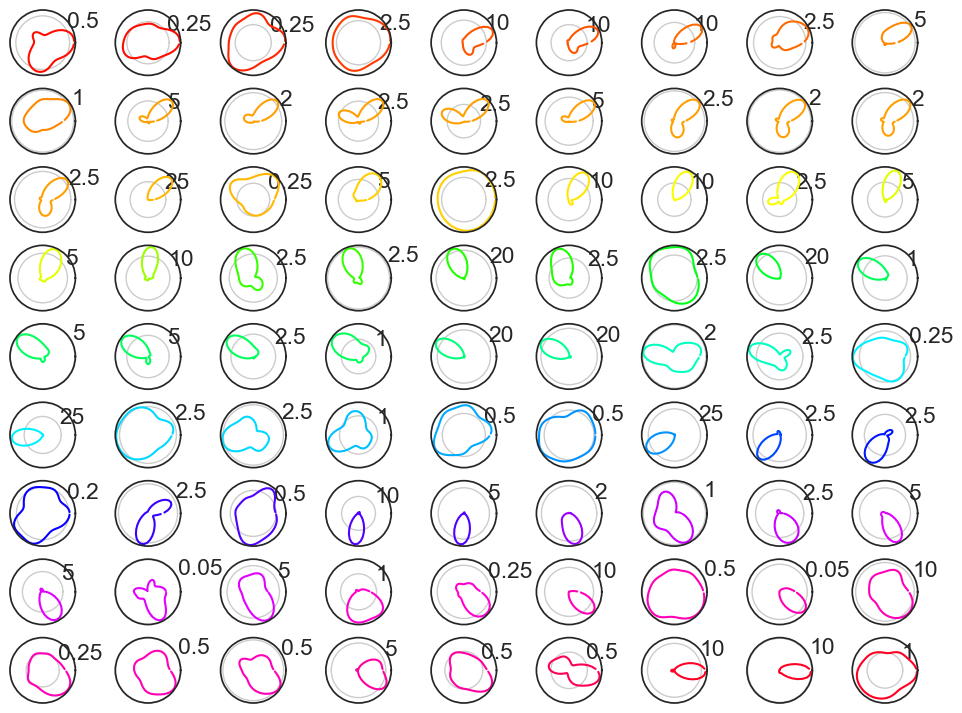

In [ ]:
# Plot all tuning curves sorted by preferred angle
fig = plot_tuning_grid(tcs, pref_ang, color, nrows=9, ncols=9)

### Von Mises Curve Fitting

Estimated Concentration (κ): 5.6623


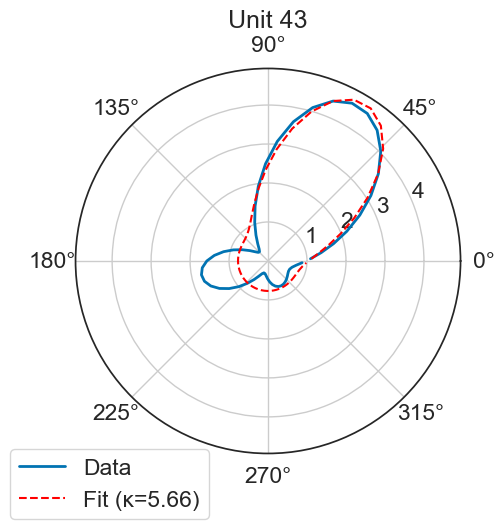

In [15]:
# Example: Fit a single unit's tuning curve
sorted_tcs = tcs.sortby(pref_ang)
unit_idx = 25

tc_data = sorted_tcs.isel(unit=unit_idx)
x_data = tc_data.coords["head_direction"].values
y_data = tc_data.values

# Fit von Mises distribution
popt, pcov = fit_von_mises(x_data, y_data)
kappa, loc, amp, offset = popt

print(f"Estimated Concentration (κ): {kappa:.4f}")

# Plot the fit on polar axes
fig, ax = plot_von_mises_fit(x_data, y_data, popt, title=f"Unit {sorted_tcs.coords['unit'].values[unit_idx]}")

In [16]:
# Fit von Mises to all tuning curves
fit_results = fit_all_tuning_curves(sorted_tcs, verbose=True)

# Save results
fit_results.to_csv(INTERIM_DATA_PATH / unit_id / "tuning_curve_fits.csv")
    
# Plot and save all fits
figures = plot_all_von_mises_fits(sorted_tcs, fit_results, save_dir=INTERIM_DATA_PATH / unit_id)
    
print(f"Saved fitted plots and parameters to {INTERIM_DATA_PATH / unit_id}")
fit_results.head()

Saved fitted plots and parameters to D:\common_datasets\ucsf\interim


,kappa,loc,amp,offset
2,0.533935,-0.786426,3.242445e-01,1.000655e-12
12,9.512992,0.065536,1.088453e-05,2.368174e-01
37,18.511156,0.117229,8.326144e-10,3.603929e-01
73,6.777929,0.246852,7.990448e-04,3.008689e+00
29,2.947080,0.293893,5.756353e-01,1.245771e+00


### Fit All Units and Filter HD cells

In [19]:
# Load previously saved fit results
fit_results = pd.read_csv(INTERIM_DATA_PATH / unit_id / "tuning_curve_fits.csv", index_col=0)
fit_results

,kappa,loc,amp,offset
2,0.533935,-0.786426,3.242445e-01,1.000655e-12
12,9.512992,0.065536,1.088453e-05,2.368174e-01
37,18.511156,0.117229,8.326144e-10,3.603929e-01
73,6.777929,0.246852,7.990448e-04,3.008689e+00
29,2.947080,0.293893,5.756353e-01,1.245771e+00
...,...,...,...,...
78,4.440556,5.748531,4.552079e-03,4.357127e-01
46,6.347883,5.973019,9.964777e-04,3.034449e-01
8,5.566557,6.231001,4.279120e-02,4.267765e-01
56,5.708660,6.213568,3.080453e-02,2.504985e-01


In [20]:
# Filter units by kappa threshold (tuning sharpness)
k_threshold = 1.5

poorly_tuned = fit_results[fit_results['kappa'] <= k_threshold]
to_be_removed = list(poorly_tuned.index)

print(f"Units with kappa <= {k_threshold} (poor tuning):")
print(to_be_removed)

Units with kappa <= 1.5 (poor tuning):
[2, 16, 17, 58, 67, 72, 13, 44, 30, 19, 18, 50, 41, 77, 71]


In [32]:
hd_spikes.set_info({"preferred_angle": pref_ang.values})
hd_spikes.set_info({'kappa': fit_results['kappa'].values})
hd_spikes

Index    rate     preferred_angle    kappa
-------  -------  -----------------  -------
0        1.438    4.89               0.53
1        0.81581  5.72               9.51
2        0.31474  0.05               18.51
3        0.85291  5.61               6.78
4        0.47537  5.51               2.95
5        1.3386   2.63               4.91
6        0.42956  3.66               6.64
...      ...      ...                ...
74       5.14371  5.2                2.71
75       3.6296   2.21               2.02
76       0.82169  5.61               4.44
77       0.80421  5.61               6.35
78       1.0221   5.72               5.57
79       0.91008  5.51               5.71
80       0.79891  5.61               0.16

In [33]:
hd_spikes.save(PROCESSED_DATA_PATH / unit_id / "hd_spikes_filtered.npz")